In [34]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [35]:
# load dataset
iris = load_iris()
# print(iris)
# features amd target
X = iris.data
y = iris.target
# feature name
print("Features Name = ",iris.feature_names)
print("Target Classes = ",iris.target_names)

Features Name =  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes =  ['setosa' 'versicolor' 'virginica']


In [36]:
# split the data 
X_train , X_test , y_train , y_test = train_test_split(X , y, test_size=0.35,random_state=42)
print("Traning Data  : ",X_train.shape)
print("Testing Data : ",X_test.shape)

Traning Data  :  (97, 4)
Testing Data :  (53, 4)


In [37]:
# create a Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100, # number of tree
    criterion='gini', # Split quality
    random_state=42
)
# train the model 
rf_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [38]:
# make predictions 
y_pred = rf_model.predict(X_test)
print("Predictions ",y_pred[:10])
print("Actual      ",y_test[:10])

Predictions  [1 0 2 1 1 0 1 2 1 1]
Actual       [1 0 2 1 1 0 1 2 1 1]


In [39]:
# Evaluate the model
# accuracy 
accuracy = accuracy_score(y_test,y_pred)
print("accuracy = ",accuracy)
# classification report 
print("classification report = \n ",classification_report(y_test,y_pred))
# confusion matrix 
print("confusion matrix = \n ",confusion_matrix(y_test,y_pred))

accuracy =  0.9811320754716981
classification report = 
                precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        17
           2       1.00      0.94      0.97        17

    accuracy                           0.98        53
   macro avg       0.98      0.98      0.98        53
weighted avg       0.98      0.98      0.98        53

confusion matrix = 
  [[19  0  0]
 [ 0 17  0]
 [ 0  1 16]]


             Feature  Importance
3   petal width (cm)    0.440939
2  petal length (cm)    0.418586
0  sepal length (cm)    0.105381
1   sepal width (cm)    0.035093


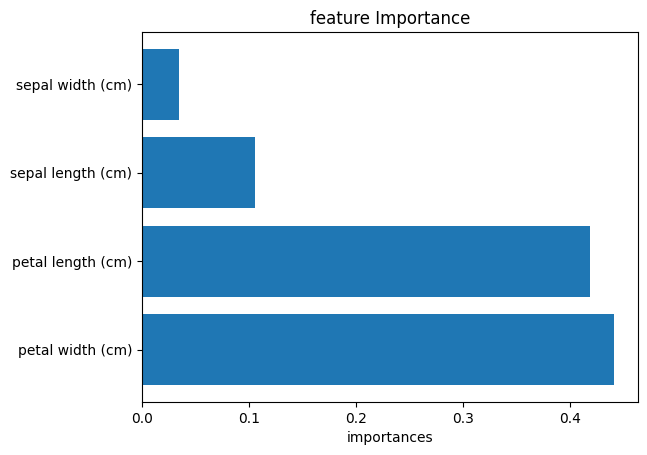

In [40]:
# feature Importance
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = iris.feature_names

# create dataframe 
feature_df = pd.DataFrame({
    'Feature':features,
    'Importance':importances
}).sort_values(by='Importance',ascending=False)
print(feature_df)

plt.barh(feature_df['Feature'],feature_df['Importance'])
plt.xlabel("importances")
plt.title("feature Importance")
plt.show()